In [ ]:
#!/usr/bin/env python
# coding: utf-8

In [1]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, LeakyReLU, BatchNormalization, Dropout
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler
import numpy as np
import h5py
import os
import scipy.io
from scipy.interpolate import interp1d
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import matplotlib.pyplot as plt

<frozen importlib._bootstrap>:219: RuntimeWarning: scipy._lib.messagestream.MessageStream size changed, may indicate binary incompatibility. Expected 56 from C header, got 64 from PyObject


In [27]:
name_format = "FCNN_Bz_run3"
print("Note: use results8.mat which has 10000 datasets; B only has positive Z values; Use mse error")
file_path = os.path.join('MATLAB_DATA', 'results8.mat')  # Replace with your actual file path

Note: use results8.mat which has 10000 datasets; B only has positive Z values; Use mse error


In [3]:
def generate_filename(base_name, extension):
    return f"{name_format}_{base_name}.{extension}"

In [4]:
def load_mat_data(file_path):
    mat_contents = scipy.io.loadmat(file_path)
    results = mat_contents['results']
    B_MAG_raw = [result['B_MAG'][0] for result in results[0]]
    EDC_MAG_raw = [result['EDC_MAG'][0] for result in results[0]]
    X_raw = [result['X'][0] for result in results[0]]  # Scaling X values
    I_raw = [result['I'][0] for result in results[0]]
    return B_MAG_raw, EDC_MAG_raw, X_raw, I_raw

In [5]:
def resample_and_smooth(X, I, new_length):
    X_new = np.linspace(6562.3, 6563.3, num=new_length)
    f = interp1d(X, I, kind='cubic', fill_value="extrapolate")
    I_new = f(X_new)
    return X_new, I_new

In [6]:
def process_data(B_MAG_raw, EDC_MAG_raw, X_raw, I_raw, fixed_length=1200):
    X_data, I_data, B_MAG_data, EDC_MAG_data = [], [], [], []
    for i in range(len(X_raw)):
        X = np.squeeze(X_raw[i])
        I = np.squeeze(I_raw[i])
        B = np.squeeze(B_MAG_raw[i])
        EDC = np.squeeze(EDC_MAG_raw[i])
        X_scaled = X * 10**10
        X_resampled, I_resampled = resample_and_smooth(X_scaled, I, fixed_length)
        X_data.append(X_resampled)
        I_data.append(I_resampled)
        B_MAG_data.append(B)
        EDC_MAG_data.append(EDC)
    return np.array(B_MAG_data), np.array(EDC_MAG_data), np.array(X_data), np.array(I_data)

In [7]:
B_MAG_data, EDC_MAG_data, X_data, I_data = load_mat_data(file_path)
B_MAG_data, EDC_MAG_data, X_data, I_data = process_data(B_MAG_data, EDC_MAG_data, X_data, I_data)

In [8]:
means = np.mean(I_data, axis=0)
stds = np.std(I_data, axis=0)
start_index, end_index = 0, I_data.shape[1] - 1

In [9]:
for i in range(I_data.shape[1]):
    if stds[i] >= 0.01:
        start_index = i
        break

In [10]:
for i in range(I_data.shape[1] - 1, -1, -1):
    if stds[i] >= 0.01:
        end_index = i
        break

In [11]:
X_resampled = X_data[0]
I_data_filtered = I_data[:, start_index:end_index + 1]
X_resampled_filtered = X_resampled[start_index:end_index + 1]
means_filtered = means[start_index:end_index + 1]
stds_filtered = stds[start_index:end_index + 1]
normalized_I = (I_data_filtered - means_filtered) / stds_filtered

In [12]:
I_data_flat = normalized_I.reshape(normalized_I.shape[0], -1)

In [13]:
target_data = np.column_stack((B_MAG_data[:, 2], EDC_MAG_data))

In [14]:
I_train, I_test, target_train, target_test = train_test_split(I_data_flat, target_data, test_size=0.2, random_state=42)

In [15]:
B_train = target_train[:, :1]
E_train = target_train[:, 1:]
B_test = target_test[:, :1]
E_test = target_test[:, 1:]

In [16]:
scaler_B3 = MinMaxScaler()
B_train_scaled = scaler_B3.fit_transform(B_train)
B_test_scaled = scaler_B3.transform(B_test)

In [17]:
scaler_E1 = MinMaxScaler()
scaler_E2 = MinMaxScaler()
scaler_E3 = MinMaxScaler()

In [18]:
E_train_scaled = np.column_stack((
    scaler_E1.fit_transform(E_train[:, 0].reshape(-1, 1)),
    scaler_E2.fit_transform(E_train[:, 1].reshape(-1, 1)),
    scaler_E3.fit_transform(E_train[:, 2].reshape(-1, 1))
))
E_test_scaled = np.column_stack((
    scaler_E1.transform(E_test[:, 0].reshape(-1, 1)),
    scaler_E2.transform(E_test[:, 1].reshape(-1, 1)),
    scaler_E3.transform(E_test[:, 2].reshape(-1, 1))
))

In [19]:
target_train_scaled = np.column_stack((B_train_scaled, E_train_scaled))
target_test_scaled = np.column_stack((B_test_scaled, E_test_scaled))

In [28]:
def custom_loss(y_true, y_pred):
    B_true, E_true = y_true[:, :1], y_true[:, 1:]
    B_pred, E_pred = y_pred[:, :1], y_pred[:, 1:]
    loss_B = tf.reduce_mean(tf.square(B_true - B_pred), axis=0)
    loss_E = tf.reduce_mean(tf.square(E_true - E_pred), axis=0)
    weight_B = tf.constant([1.0])
    weight_E = tf.constant([1.0, 1.0, 1.0])
    total_loss = tf.reduce_sum(weight_B * loss_B) + tf.reduce_sum(weight_E * loss_E)
    return total_loss
    
model_save_path = os.path.join("/home/botingl/machine learning", generate_filename("model", "h5"))
model = tf.keras.models.load_model(model_save_path, custom_objects={'custom_loss': custom_loss})
print("Model loaded successfully.")

Model loaded successfully.


In [22]:
def evaluate_whole_model(y_true, y_pred):
    nmse = mean_squared_error(y_true, y_pred) / np.var(y_true)
    rmae = mean_absolute_error(y_true, y_pred) / np.mean(np.abs(y_true))
    r2 = r2_score(y_true, y_pred)
    return nmse, rmae, r2

In [23]:
def evaluate_components(y_true, y_pred):
    mse = mean_squared_error(y_true, y_pred)
    mae = mean_absolute_error(y_true, y_pred)
    r2 = r2_score(y_true, y_pred)
    return mse, mae, r2

In [29]:
print("Start to evaluate the training set.", flush=True)
train_subset_indices = np.random.choice(len(I_train), size=1000, replace=False)
train_input_data_subset = I_train[train_subset_indices]
train_target_data_subset = target_train_scaled[train_subset_indices]

Start to evaluate the training set.


In [30]:
predictions_train = model.predict(train_input_data_subset)

32/32 [==============================] - 1s 2ms/step


In [31]:
B_pred_train = scaler_B3.inverse_transform(predictions_train[:, 0].reshape(-1, 1))
E_pred_train = np.column_stack((
    scaler_E1.inverse_transform(predictions_train[:, 1].reshape(-1, 1)),
    scaler_E2.inverse_transform(predictions_train[:, 2].reshape(-1, 1)),
    scaler_E3.inverse_transform(predictions_train[:, 3].reshape(-1, 1))
))

In [32]:
B_true_train = scaler_B3.inverse_transform(train_target_data_subset[:, 0].reshape(-1, 1))
E_true_train = np.column_stack((
    scaler_E1.inverse_transform(train_target_data_subset[:, 1].reshape(-1, 1)),
    scaler_E2.inverse_transform(train_target_data_subset[:, 2].reshape(-1, 1)),
    scaler_E3.inverse_transform(train_target_data_subset[:, 3].reshape(-1, 1))
))

In [33]:
true_train_combined = np.column_stack((B_true_train, E_true_train))
pred_train_combined = np.column_stack((B_pred_train, E_pred_train))

In [34]:
nmse_train, rmae_train, r2_whole_model_train = evaluate_whole_model(true_train_combined, pred_train_combined)
print(f"Whole Model NMSE: {nmse_train}, rMAE: {rmae_train}, R²: {r2_whole_model_train}")

Whole Model NMSE: 0.013198471429063425, rMAE: 0.046132860166949896, R²: 0.9780748651182072


In [35]:
mse_train_B3, mae_train_B3, r2_train_B3 = evaluate_components(B_true_train, B_pred_train)
mse_train_E1, mae_train_E1, r2_train_E1 = evaluate_components(E_true_train[:, 0], E_pred_train[:, 0])
mse_train_E2, mae_train_E2, r2_train_E2 = evaluate_components(E_true_train[:, 1], E_pred_train[:, 1])
mse_train_E3, mae_train_E3, r2_train_E3 = evaluate_components(E_true_train[:, 2], E_pred_train[:, 2])

In [36]:
print(f"B3: MSE = {mse_train_B3}, MAE = {mae_train_B3}, R² = {r2_train_B3}")
print(f"E1: MSE = {mse_train_E1}, MAE = {mae_train_E1}, R² = {r2_train_E1}")
print(f"E2: MSE = {mse_train_E2}, MAE = {mae_train_E2}, R² = {r2_train_E2}")
print(f"E3: MSE = {mse_train_E3}, MAE = {mae_train_E3}, R² = {r2_train_E3}")

B3: MSE = 3.34767433086582e-05, MAE = 0.004351563601625541, R² = 0.995652893500472
E1: MSE = 10078.48083334221, MAE = 61.86080409372669, R² = 0.9643191941879589
E2: MSE = 1939.6335481033595, MAE = 30.023890919421792, R² = 0.9928496762949023
E3: MSE = 10791.995473567391, MAE = 60.40022156845711, R² = 0.9594776964894953


In [37]:
# metrics_train_file = os.path.join("/home/botingl/machine learning", generate_filename("evaluation_metrics_train", "txt"))
# with open(metrics_train_file, "w") as f:
#     f.write(f"Whole Model NMSE: {nmse_train}\n")
#     f.write(f"rMAE: {rmae_train}\n")
#     f.write(f"R²: {r2_whole_model_train}\n")
#     f.write(f"B3: MSE = {mse_train_B3}, MAE = {mae_train_B3}, R² = {r2_train_B3}\n")
#     f.write(f"E1: MSE = {mse_train_E1}, MAE = {mae_train_E1}, R² = {r2_train_E1}\n")
#     f.write(f"E2: MSE = {mse_train_E2}, MAE = {mae_train_E2}, R² = {r2_train_E2}\n")
#     f.write(f"E3: MSE = {mse_train_E3}, MAE = {mae_train_E3}, R² = {r2_train_E3}\n")

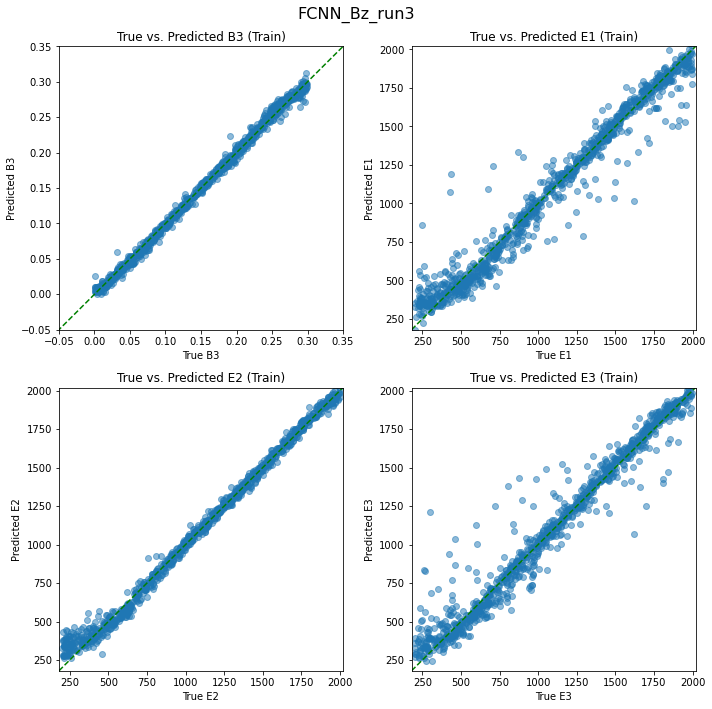

In [40]:
plt.figure(figsize=(10, 10))
plt.subplot(2, 2, 1)
plt.scatter(B_true_train, B_pred_train, alpha=0.5)
plt.plot([-0.1, 1.1], [-0.1, 1.1], 'g--')
plt.xlim(-0.05, 0.35)
plt.ylim(-0.05, 0.35)
plt.xlabel('True B3')
plt.ylabel('Predicted B3')
plt.title('True vs. Predicted B3 (Train)')

plt.subplot(2, 2, 2)
plt.scatter(E_true_train[:, 0], E_pred_train[:, 0], alpha=0.5)
plt.plot([180, 2020], [180, 2020], 'g--')
plt.xlim(180, 2020)
plt.ylim(180, 2020)
plt.xlabel('True E1')
plt.ylabel('Predicted E1')
plt.title('True vs. Predicted E1 (Train)')

plt.subplot(2, 2, 3)
plt.scatter(E_true_train[:, 1], E_pred_train[:, 1], alpha=0.5)
plt.plot([180, 2020], [180, 2020], 'g--')
plt.xlim(180, 2020)
plt.ylim(180, 2020)
plt.xlabel('True E2')
plt.ylabel('Predicted E2')
plt.title('True vs. Predicted E2 (Train)')

plt.subplot(2, 2, 4)
plt.scatter(E_true_train[:, 2], E_pred_train[:, 2], alpha=0.5)
plt.plot([180, 2020], [180, 2020], 'g--')
plt.xlim(180, 2020)
plt.ylim(180, 2020)
plt.xlabel('True E3')
plt.ylabel('Predicted E3')
plt.title('True vs. Predicted E3 (Train)')

plt.suptitle(f'{name_format}', fontsize=16)

plt.tight_layout(rect=[0, 0, 1, 1])  # Adjust layout to avoid overlap with suptitle
# figure_test_file = os.path.join("/home/botingl/machine learning", generate_filename("true_vs_predictions_test", "png"))
# plt.savefig(figure_test_file, dpi=300, facecolor='white')
plt.show()

In [41]:
print("Training set evaluation done.", flush=True)

Training set evaluation done.


In [42]:
print("Start to evaluate the testing set.", flush=True)
predictions_test = model.predict(I_test)

Start to evaluate the testing set.
63/63 [==============================] - 0s 2ms/step


In [43]:
B_pred_test = scaler_B3.inverse_transform(predictions_test[:, 0].reshape(-1, 1))
E_pred_test = np.column_stack((
    scaler_E1.inverse_transform(predictions_test[:, 1].reshape(-1, 1)),
    scaler_E2.inverse_transform(predictions_test[:, 2].reshape(-1, 1)),
    scaler_E3.inverse_transform(predictions_test[:, 3].reshape(-1, 1))
))

In [44]:
B_true_test = scaler_B3.inverse_transform(target_test_scaled[:, 0].reshape(-1, 1))
E_true_test = np.column_stack((
    scaler_E1.inverse_transform(target_test_scaled[:, 1].reshape(-1, 1)),
    scaler_E2.inverse_transform(target_test_scaled[:, 2].reshape(-1, 1)),
    scaler_E3.inverse_transform(target_test_scaled[:, 3].reshape(-1, 1))
))

In [45]:
true_test_combined = np.column_stack((B_true_test, E_true_test))
pred_test_combined = np.column_stack((B_pred_test, E_pred_test))

In [46]:
nmse_test, rmae_test, r2_whole_model_test = evaluate_whole_model(true_test_combined, pred_test_combined)
print(f"Whole Model NMSE: {nmse_test}, rMAE: {rmae_test}, R²: {r2_whole_model_test}")

Whole Model NMSE: 0.015299959790150166, rMAE: 0.04892338004279789, R²: 0.9743810175722578


In [47]:
mse_test_B3, mae_test_B3, r2_test_B3 = evaluate_components(B_true_test, B_pred_test)
mse_test_E1, mae_test_E1, r2_test_E1 = evaluate_components(E_true_test[:, 0], E_pred_test[:, 0])
mse_test_E2, mae_test_E2, r2_test_E2 = evaluate_components(E_true_test[:, 1], E_pred_test[:, 1])
mse_test_E3, mae_test_E3, r2_test_E3 = evaluate_components(E_true_test[:, 2], E_pred_test[:, 2])

In [48]:
print(f"B3: MSE = {mse_test_B3}, MAE = {mae_test_B3}, R² = {r2_test_B3}")
print(f"E1: MSE = {mse_test_E1}, MAE = {mae_test_E1}, R² = {r2_test_E1}")
print(f"E2: MSE = {mse_test_E2}, MAE = {mae_test_E2}, R² = {r2_test_E2}")
print(f"E3: MSE = {mse_test_E3}, MAE = {mae_test_E3}, R² = {r2_test_E3}")

B3: MSE = 4.0802561080180926e-05, MAE = 0.004675826860525948, R² = 0.9945772810432469
E1: MSE = 12504.111165992408, MAE = 68.20116423706268, R² = 0.9543740297488775
E2: MSE = 1977.6252881386163, MAE = 30.475246375081333, R² = 0.9924253120005144
E3: MSE = 11894.557706033036, MAE = 63.67781988599926, R² = 0.9561474474963926


In [49]:
# metrics_train_file = os.path.join("/home/botingl/machine learning", generate_filename("evaluation_metrics_test", "txt"))
# with open(metrics_train_file, "w") as f:
#     f.write(f"Whole Model NMSE: {nmse_test}\n")
#     f.write(f"rMAE: {rmae_test}\n")
#     f.write(f"R²: {r2_whole_model_test}\n")
#     f.write(f"B3: MSE = {mse_test_B3}, MAE = {mae_test_B3}, R² = {r2_test_B3}\n")
#     f.write(f"E1: MSE = {mse_test_E1}, MAE = {mae_test_E1}, R² = {r2_test_E1}\n")
#     f.write(f"E2: MSE = {mse_test_E2}, MAE = {mae_test_E2}, R² = {r2_test_E2}\n")
#     f.write(f"E3: MSE = {mse_test_E3}, MAE = {mae_test_E3}, R² = {r2_test_E3}\n")

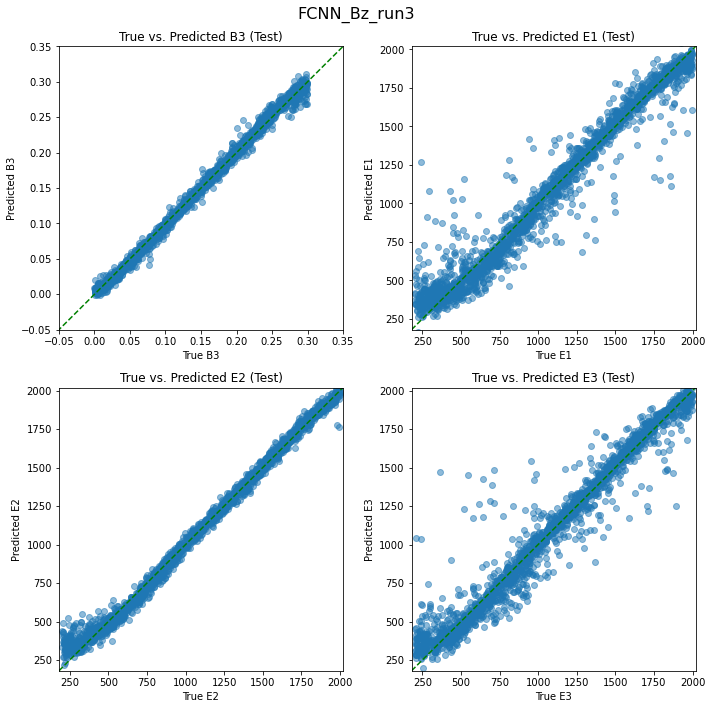

In [51]:
plt.figure(figsize=(10, 10))
plt.subplot(2, 2, 1)
plt.scatter(B_true_test, B_pred_test, alpha=0.5)
plt.plot([-0.1, 1.1], [-0.1, 1.1], 'g--')
plt.xlim(-0.05, 0.35)
plt.ylim(-0.05, 0.35)
plt.xlabel('True B3')
plt.ylabel('Predicted B3')
plt.title('True vs. Predicted B3 (Test)')

plt.subplot(2, 2, 2)
plt.scatter(E_true_test[:, 0], E_pred_test[:, 0], alpha=0.5)
plt.plot([180, 2020], [180, 2020], 'g--')
plt.xlim(180, 2020)
plt.ylim(180, 2020)
plt.xlabel('True E1')
plt.ylabel('Predicted E1')
plt.title('True vs. Predicted E1 (Test)')

plt.subplot(2, 2, 3)
plt.scatter(E_true_test[:, 1], E_pred_test[:, 1], alpha=0.5)
plt.plot([180, 2020], [180, 2020], 'g--')
plt.xlim(180, 2020)
plt.ylim(180, 2020)
plt.xlabel('True E2')
plt.ylabel('Predicted E2')
plt.title('True vs. Predicted E2 (Test)')

plt.subplot(2, 2, 4)
plt.scatter(E_true_test[:, 2], E_pred_test[:, 2], alpha=0.5)
plt.plot([180, 2020], [180, 2020], 'g--')
plt.xlim(180, 2020)
plt.ylim(180, 2020)
plt.xlabel('True E3')
plt.ylabel('Predicted E3')
plt.title('True vs. Predicted E3 (Test)')

plt.suptitle(f'{name_format}', fontsize=16)

plt.tight_layout(rect=[0, 0, 1, 1])
# figure_test_file = os.path.join("/home/botingl/machine learning", generate_filename("true_vs_predictions_test", "png"))
# plt.savefig(figure_test_file, dpi=300, facecolor='white')
plt.show()